# Análisis de Factores Financieros que Influyen en la Aprobación de Créditos

## Estructura del proyecto

| Sección | Contenido |
|---|---|
| 0. Configuración del Entorno | Importación de librerías y carga del dataset |
| 1. Comprensión del Negocio | Descripción del problema, objetivos y metas |
| 2. Comprensión de los Datos | Variables, distribuciones, correlaciones y perfilamiento |
| 3. Preparación de los Datos | Outliers, transformaciones, codificación, SMOTE |
| 4. Modelado | K-Means (clustering) + Regresión Logística, Random Forest, XGBoost |
| 5. Evaluación | AUC-ROC, matrices de confusión, feature importance |
| 6. Despliegue | Exportación y descarga del modelo |
| 7. Conclusiones | Hallazgos por objetivo |

---
# 1. Comprensión del Negocio



## 1.1 Descripción del problema

Las entidades financieras enfrentan el desafío de evaluar objetivamente las solicitudes de crédito, equilibrando la inclusión financiera con el control del riesgo. Una decisión basada únicamente en criterios subjetivos puede generar pérdidas por cartera morosa o exclusión injustificada de solicitantes viables. Un modelo predictivo permite sistematizar y objetivar esa decisión a partir de variables financieras, crediticias y personales del solicitante.




##1.2 Objetivos
**Objetivo 1:** Identificar las variables con mayor capacidad para diferenciar solicitudes aprobadas de rechazadas  

**Objetivo 2:** Segmentar los solicitantes mediante K-Means

**Objetivo 3:** Construir y comparar modelos de clasificación supervisada


##1.3 Metas

**Objetivo 1:** Identificar las variables con mayor capacidad para diferenciar solicitudes aprobadas de rechazadas  
* Meta 1.1: Distribuciones de variables numéricas (boxplots, histogramas)  
* Meta 1.2: Tasas de aprobación por categorías (loan_intent, person_education, person_home_ownership)  
* Meta 1.3: Matriz de correlación entre variables numéricas  

**Objetivo 2:** Segmentar los solicitantes mediante K-Means  
* Meta 2.1: Aplicar K-Means sobre variables financieras y demográficas (excluyendo loan_status)  
* Meta 2.2: Caracterizar cada cluster con perfil promedio  
* Meta 2.3: Analizar tasa de aprobación por cluster  

**Objetivo 3:** Construir y comparar modelos de clasificación supervisada  
* Meta 3.1: Preparación del dataset (outliers, transformaciones, SMOTE)  
* Meta 3.2: Entrenar Regresión Logística, Random Forest y XGBoost  
* Meta 3.3: Comparar modelos con AUC-ROC, Precision, Recall y F1-Score  

---
# 2. Comprensión de los Datos

## 2.1 Variables del Dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `person_age` | Cuantitativa continua (razón) | Edad del solicitante en años |
| `person_gender` | Cualitativa nominal dicotómica | Género: male / female |
| `person_education` | Cualitativa **ordinal** | High School < Associate < Bachelor < Master < Doctorate |
| `person_income` | Cuantitativa continua (razón) | Ingreso anual en dólares |
| `person_emp_exp` | Cuantitativa discreta (razón) | Años de experiencia laboral |
| `person_home_ownership` | Cualitativa nominal politómica | RENT / OWN / MORTGAGE / OTHER |
| `loan_amnt` | Cuantitativa continua (razón) | Monto del préstamo solicitado |
| `loan_intent` | Cualitativa nominal politómica | Propósito del crédito (6 categorías) |
| `loan_int_rate` | Cuantitativa continua (razón) | Tasa de interés asignada (%) |
| `loan_percent_income` | Cuantitativa continua (razón) | Proporción préstamo / ingreso anual |
| `cb_person_cred_hist_length` | Cuantitativa discreta (razón) | Años de historial crediticio |
| `credit_score` | Cuantitativa continua (intervalo) | Puntaje crediticio del solicitante |
| `previous_loan_defaults_on_file` | Cualitativa nominal dicotómica | Incumplimientos previos: Yes / No |
| `loan_status` | **Variable objetivo** (binaria) | 1 = Aprobado, 0 = Rechazado |


##2.2 Importación librerias - carga dataset

In [1]:
!pip install -q xgboost imbalanced-learn shap
!pip install -q ydata-profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_score, recall_score,
                              f1_score, silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings("ignore")

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
df = pd.read_csv("/content/loan_data.csv")

print(f"Shape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
display(df.head())

Shape: (45000, 14)

Columnas: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

Primeras filas:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
print("Tipos de variables:")
print(df.dtypes)
print(f"\nValores ausentes:")
print(df.isnull().sum())
print(f"\nRegistros duplicados: {df.duplicated().sum()}")
print(f"\nDistribución loan_status:")
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True).round(3))

Tipos de variables:
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

Valores ausentes:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0

## 2.3 Distribución de la variable objetivo — `loan_status`

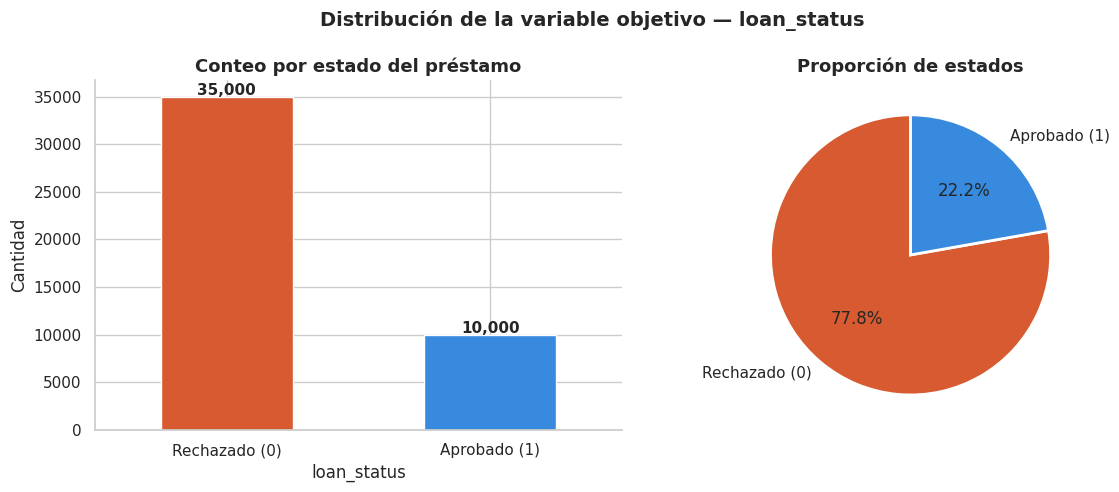

In [4]:
conteo = df["loan_status"].value_counts().sort_index()
etiquetas = {0: "Rechazado (0)", 1: "Aprobado (1)"}
labels_plot = [etiquetas[i] for i in conteo.index]
colores = ["#D85A30", "#378ADD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

conteo.plot(kind="bar", ax=axes[0], color=colores, edgecolor="white", width=0.5)
axes[0].set_title("Conteo por estado del préstamo", fontsize=13, fontweight="bold")
axes[0].set_xticklabels(labels_plot, rotation=0)
axes[0].set_ylabel("Cantidad")
for bar, val in zip(axes[0].patches, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")

axes[1].pie(conteo, labels=labels_plot, autopct="%1.1f%%",
            colors=colores, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporción de estados", fontsize=13, fontweight="bold")

plt.suptitle("Distribución de la variable objetivo — loan_status",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.4 Distribuciones de variables numéricas

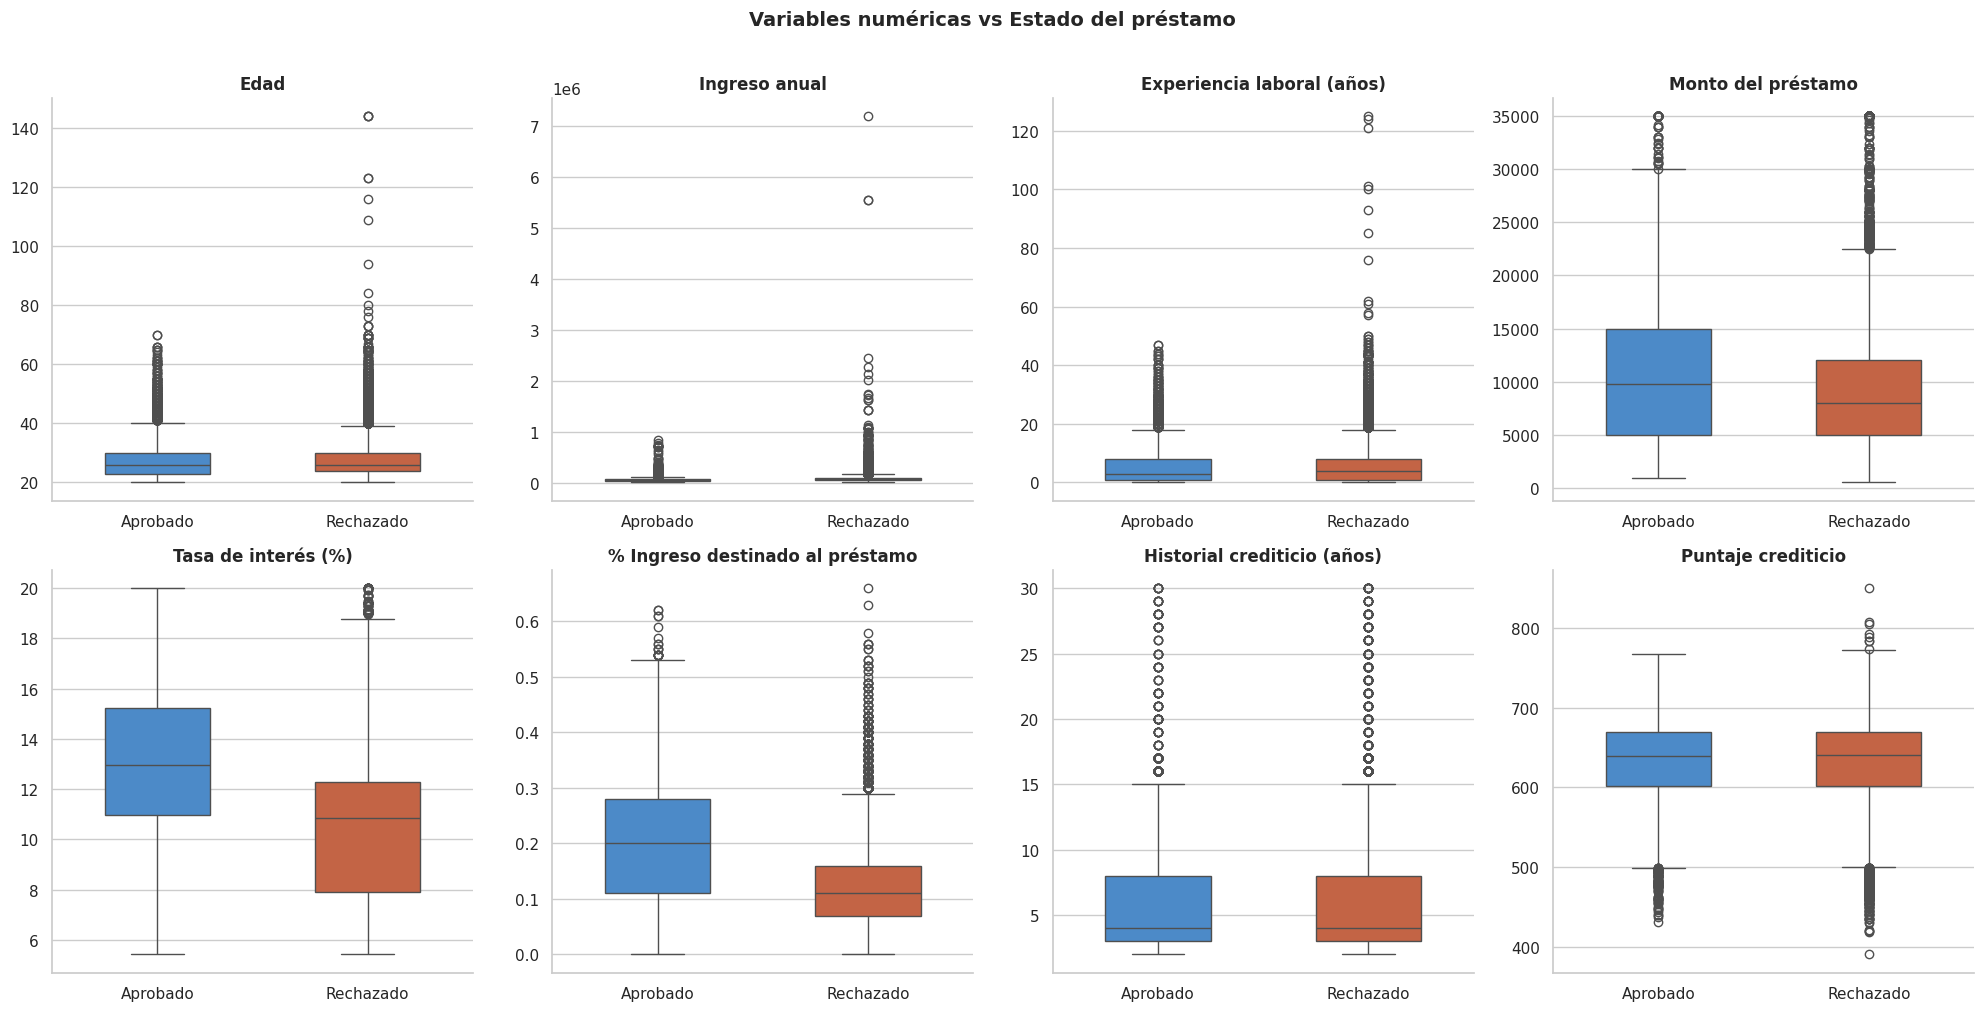

Estadísticas promedio por grupo:


,Edad,Ingreso anual,Experiencia laboral (años),Monto del préstamo,Tasa de interés (%),% Ingreso destinado al préstamo,Historial crediticio (años),Puntaje crediticio
loan_status,,,,,,,,
0,27.83,86157.04,5.48,9219.58,10.48,0.12,5.90,632.81
1,27.52,59886.10,5.18,10855.69,12.86,0.20,5.76,631.89


In [5]:
numericas = ["person_age", "person_income", "person_emp_exp",
             "loan_amnt", "loan_int_rate", "loan_percent_income",
             "cb_person_cred_hist_length", "credit_score"]

nombres_es = {
    "person_age": "Edad",
    "person_income": "Ingreso anual",
    "person_emp_exp": "Experiencia laboral (años)",
    "loan_amnt": "Monto del préstamo",
    "loan_int_rate": "Tasa de interés (%)",
    "loan_percent_income": "% Ingreso destinado al préstamo",
    "cb_person_cred_hist_length": "Historial crediticio (años)",
    "credit_score": "Puntaje crediticio"
}

df_plot = df.copy()
df_plot["Estado"] = df_plot["loan_status"].map({0: "Rechazado", 1: "Aprobado"})
paleta = {"Rechazado": "#D85A30", "Aprobado": "#378ADD"}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(x="Estado", y=col, data=df_plot, ax=axes[i],
                hue="Estado", palette=paleta, legend=False, width=0.5)
    axes[i].set_title(nombres_es[col], fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Variables numéricas vs Estado del préstamo",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Estadísticas promedio por grupo:")
display(df.groupby("loan_status")[numericas].mean().round(2).rename(columns=nombres_es))

In [6]:
# Estadísticas descriptivas por grupo
print("Medidas de tendencia central y dispersión por estado del préstamo:")
display(df.groupby("loan_status")[numericas].agg(["mean", "median", "std"]).round(2))


Medidas de tendencia central y dispersión por estado del préstamo:


person_age              person_income                     \
                  mean median   std          mean   median       std   
loan_status                                                            
0                27.83   26.0  6.07      86157.04  72928.0  87035.24   
1                27.52   26.0  5.94      59886.10  50629.0  45338.32   

            person_emp_exp              loan_amnt  ... loan_int_rate  \
                      mean median   std      mean  ...           std   
loan_status                                        ...                 
0                     5.48    4.0  6.10   9219.58  ...          2.73   
1                     5.18    3.0  5.91  10855.69  ...          3.07   

            loan_percent_income              cb_person_cred_hist_length  \
                           mean median   std                       mean   
loan_status                                                               
0                          0.12   0.11  0.07                       5.90   
1                          0.20   0.20  0.11                       5.76   

                         credit_score                
            median   std         mean median    std  
loan_status                                          
0              4.0  3.87       632.81  640.0  50.48  
1              4.0  3.90       631.89  639.0  50.29  

[2 rows x 24 columns]

## 2.5 Variables categóricas vs loan_status — Meta 1.2

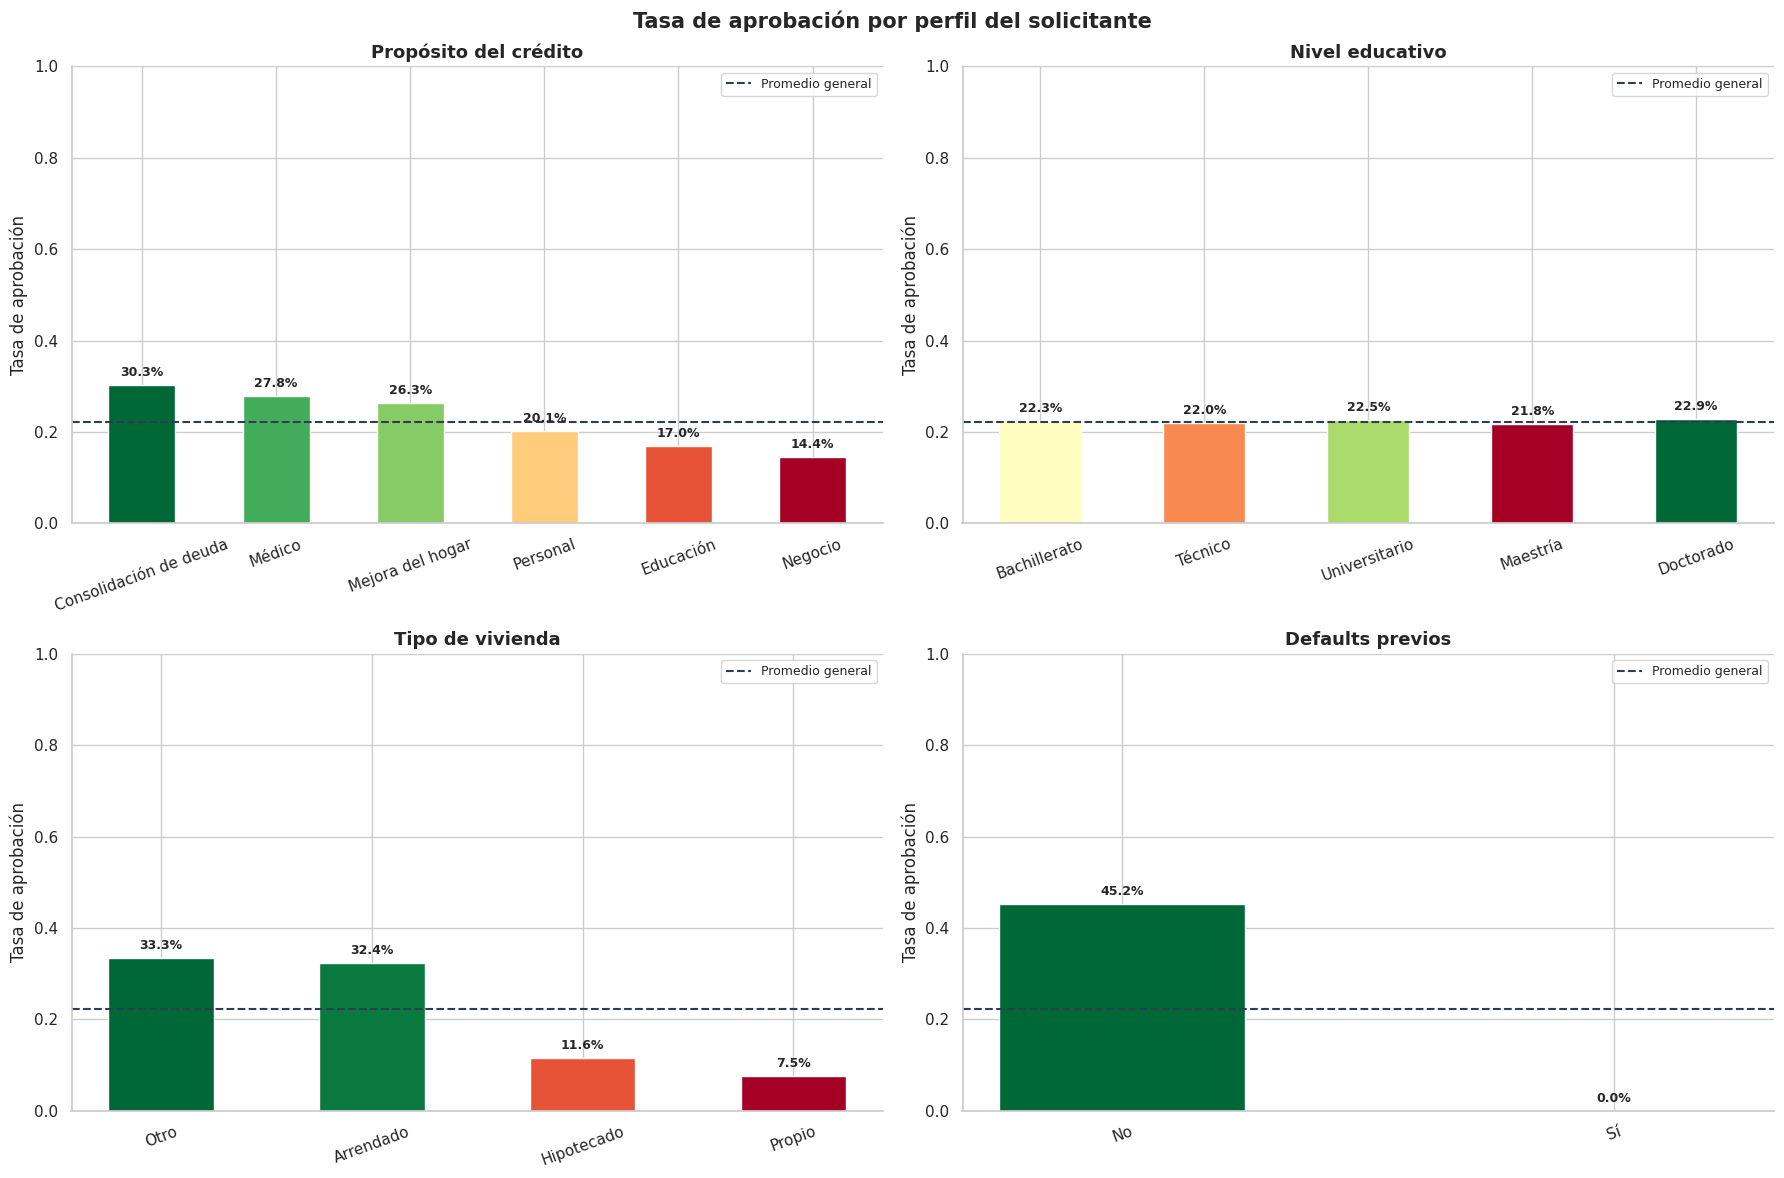

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

orden_edu = ["High School", "Associate", "Bachelor", "Master", "Doctorate"]

traducciones = {
    # loan_intent
    "PERSONAL":     "Personal",
    "EDUCATION":    "Educación",
    "MEDICAL":      "Médico",
    "VENTURE":      "Negocio",
    "HOMEIMPROVEMENT": "Mejora del hogar",
    "DEBTCONSOLIDATION": "Consolidación de deuda",
    # person_education
    "High School":  "Bachillerato",
    "Associate":    "Técnico",
    "Bachelor":     "Universitario",
    "Master":       "Maestría",
    "Doctorate":    "Doctorado",
    # person_home_ownership
    "RENT":         "Arrendado",
    "OWN":          "Propio",
    "MORTGAGE":     "Hipotecado",
    "OTHER":        "Otro",
    # previous_loan_defaults_on_file
    "Yes":          "Sí",
    "No":           "No",
}

orden_edu_es = ["Bachillerato", "Técnico", "Universitario", "Maestría", "Doctorado"]

categoricas = [
    ("loan_intent",                    "Propósito del crédito",  axes[0, 0], None),
    ("person_education",               "Nivel educativo",         axes[0, 1], orden_edu),
    ("person_home_ownership",          "Tipo de vivienda",        axes[1, 0], None),
    ("previous_loan_defaults_on_file", "Defaults previos",        axes[1, 1], None),
]

for col, titulo, ax, orden in categoricas:
    if orden:
        tabla = df.groupby(col)["loan_status"].mean().reindex(orden)
    else:
        tabla = df.groupby(col)["loan_status"].mean().sort_values(ascending=False)

    # Traducir el índice
    tabla.index = [traducciones.get(v, v) for v in tabla.index]

    # Reordenar educación ya con nombres en español
    if orden:
        tabla = tabla.reindex(orden_edu_es)

    norm = plt.Normalize(tabla.min(), tabla.max())
    cmap = plt.colormaps["RdYlGn"]
    colores_bar = [cmap(norm(v)) for v in tabla.values]

    bars = ax.bar(tabla.index, tabla.values, color=colores_bar,
                  edgecolor="white", width=0.5)
    ax.axhline(df["loan_status"].mean(), color="#2c3e50",
               linestyle="--", lw=1.5, label="Promedio general")
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_ylabel("Tasa de aprobación")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, tabla.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.1%}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Tasa de aprobación por perfil del solicitante",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

##2.6 Brecha de aprobación por genero

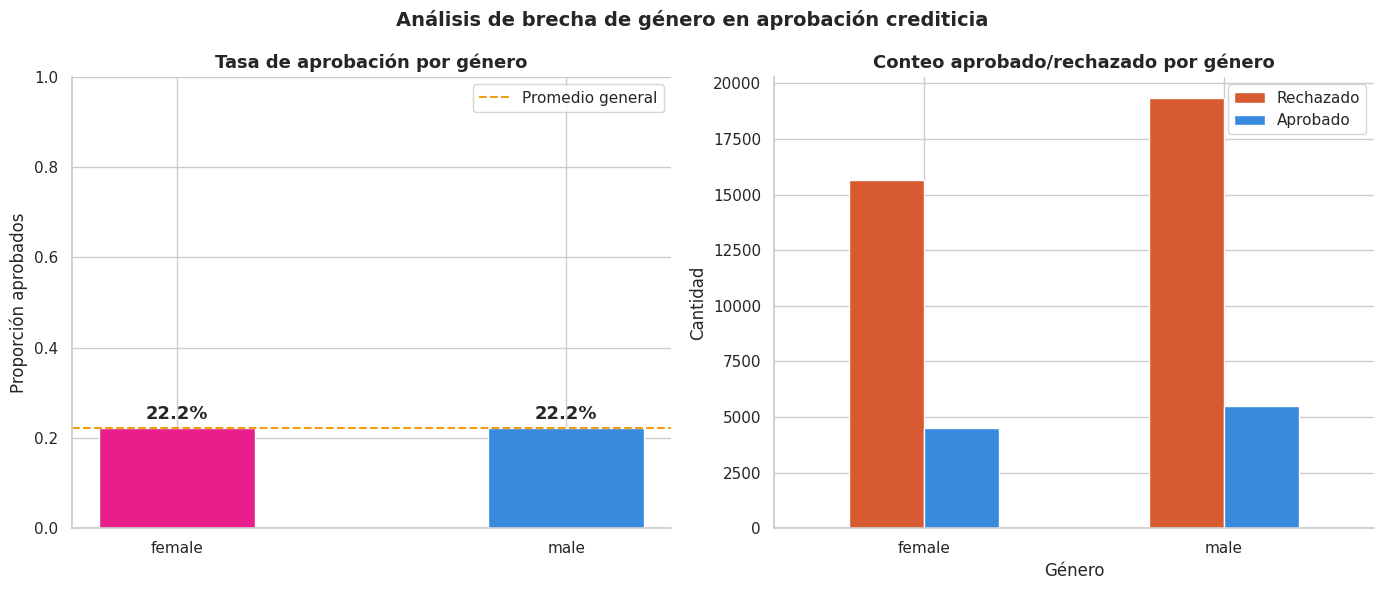

Tasa aprobación hombres : 22.2%
Tasa aprobación mujeres : 22.2%
Brecha de género        : -0.0%

→ Esta brecha se documenta como hallazgo ético del proyecto.


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tabla_gen = df.groupby("person_gender")["loan_status"].mean().sort_values(ascending=False)
colores_gen = ["#378ADD" if g == "male" else "#e91e8c" for g in tabla_gen.index]

bars = axes[0].bar(tabla_gen.index, tabla_gen.values,
                   color=colores_gen, edgecolor="white", width=0.4)
axes[0].axhline(df["loan_status"].mean(), color="#f39c12",
                linestyle="--", lw=1.5, label="Promedio general")
axes[0].set_title("Tasa de aprobación por género", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Proporción aprobados")
axes[0].set_ylim(0, 1)
axes[0].legend()
for bar, val in zip(bars, tabla_gen.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.1%}", ha="center", fontsize=13, fontweight="bold")

tabla_cnt = df.groupby(["person_gender", "loan_status"]).size().unstack()
tabla_cnt.plot(kind="bar", ax=axes[1],
               color=["#D85A30", "#378ADD"], edgecolor="white", width=0.5)
axes[1].set_title("Conteo aprobado/rechazado por género", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Cantidad")
axes[1].legend(["Rechazado", "Aprobado"])
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Análisis de brecha de género en aprobación crediticia",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

brecha = tabla_gen["male"] - tabla_gen["female"]
print(f"Tasa aprobación hombres : {tabla_gen['male']:.1%}")
print(f"Tasa aprobación mujeres : {tabla_gen['female']:.1%}")
print(f"Brecha de género        : {brecha:.1%}")
print("\n→ Esta brecha se documenta como hallazgo ético del proyecto.")

##2.7 Matriz de corelaccion

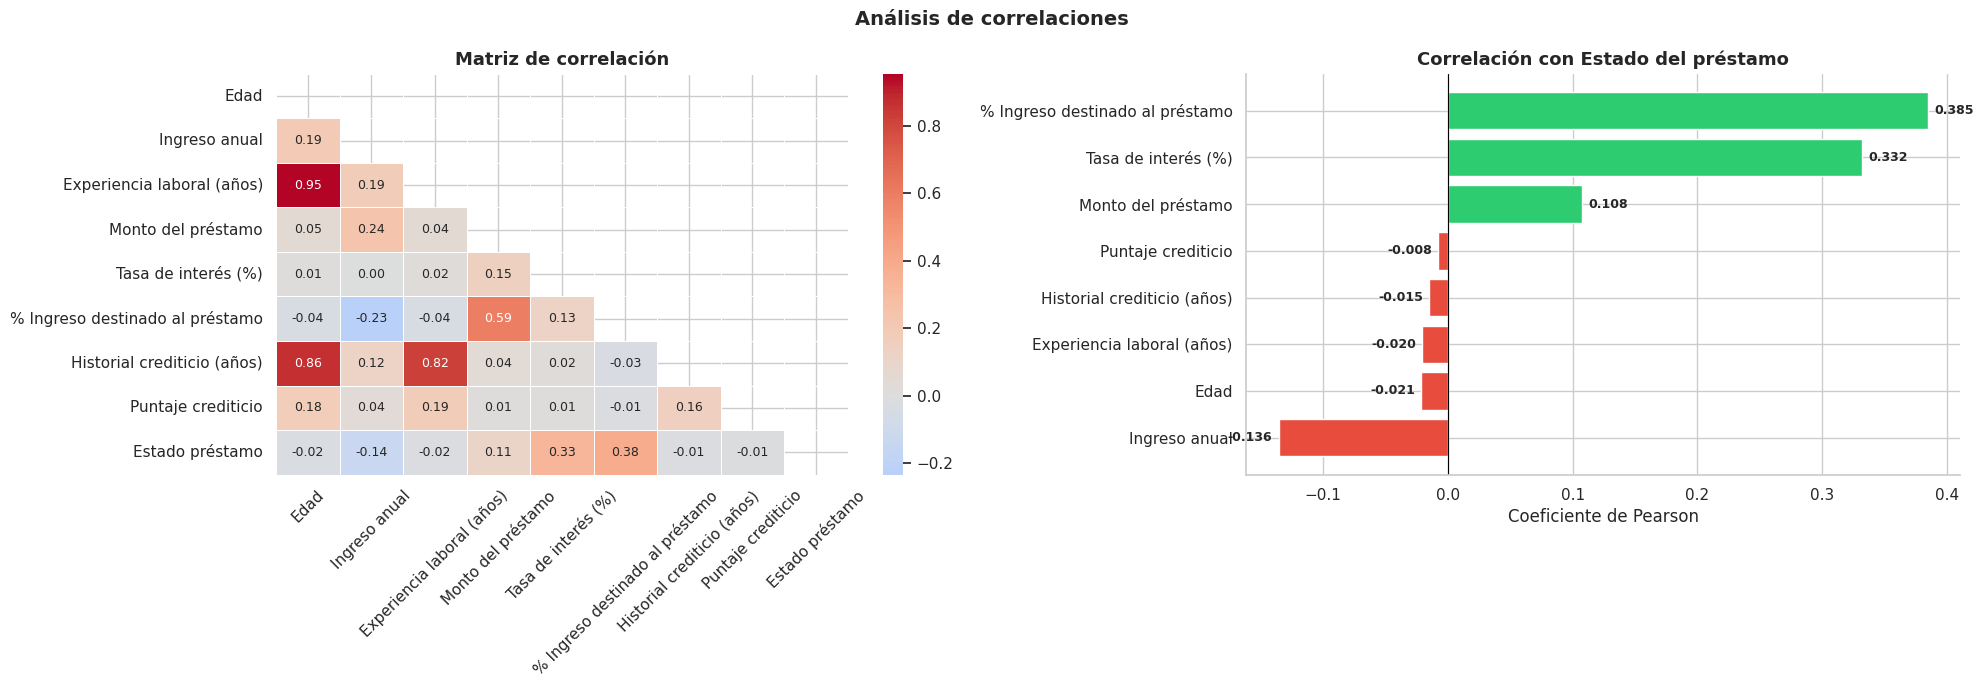

In [9]:
corr_vars = numericas + ["loan_status"]
corr_matrix = df[corr_vars].corr()

# Renombrar columnas e índice al español
nombres_es_completo = {**nombres_es, "loan_status": "Estado préstamo"}
corr_matrix = corr_matrix.rename(index=nombres_es_completo, columns=nombres_es_completo)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0], mask=mask,
            annot_kws={"size": 9})
axes[0].set_title("Matriz de correlación", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

corr_target = corr_matrix["Estado préstamo"].drop("Estado préstamo").sort_values()
colores_corr = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_target.values]
bars = axes[1].barh(corr_target.index, corr_target.values,
                    color=colores_corr, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación con Estado del préstamo", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Coeficiente de Pearson")
for bar, val in zip(bars, corr_target.values):
    xpos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha = "left" if val >= 0 else "right"
    axes[1].text(xpos, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", ha=ha, fontsize=9, fontweight="bold")

plt.suptitle("Análisis de correlaciones", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##2.8 Reporte de perfilamiento

In [10]:
from ydata_profiling import ProfileReport
from IPython.display import display

profile = ProfileReport(
    df,
    title="Análisis Exploratorio — Loan Data",
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:02<00:00,  6.17it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

##2.9 Conclusión:

#####El análisis exploratorio revela que `loan_percent_income`, `loan_int_rate` y `person_income` son las variables numéricas con mayor capacidad discriminante entre aprobados y rechazados (correlaciones de +0.39, +0.33 y -0.24 respectivamente). La variable `previous_loan_defaults_on_file` muestra la brecha de aprobación más pronunciada: 45.3% de aprobación sin incumplimientos vs 0% con incumplimientos.

#####Variables como `person_gender` (Δ = 0.1%), `person_education` (Δ = 0.9%), `person_age` (r = -0.018), `credit_score` (r = -0.007), `person_emp_exp` (r = -0.017) y `cb_person_cred_hist_length` (r = -0.013) no muestran capacidad discriminante significativa y serán excluidas del modelo.


---
#3. Preparación de los Datos

## 3.1 Tratamiento de outliers

=== OUTLIERS IDENTIFICADOS ===
Edad > 100:                    7 registros
Experiencia laboral > 60 años: 10 registros
Ingreso anual > percentil 99:  450 registros


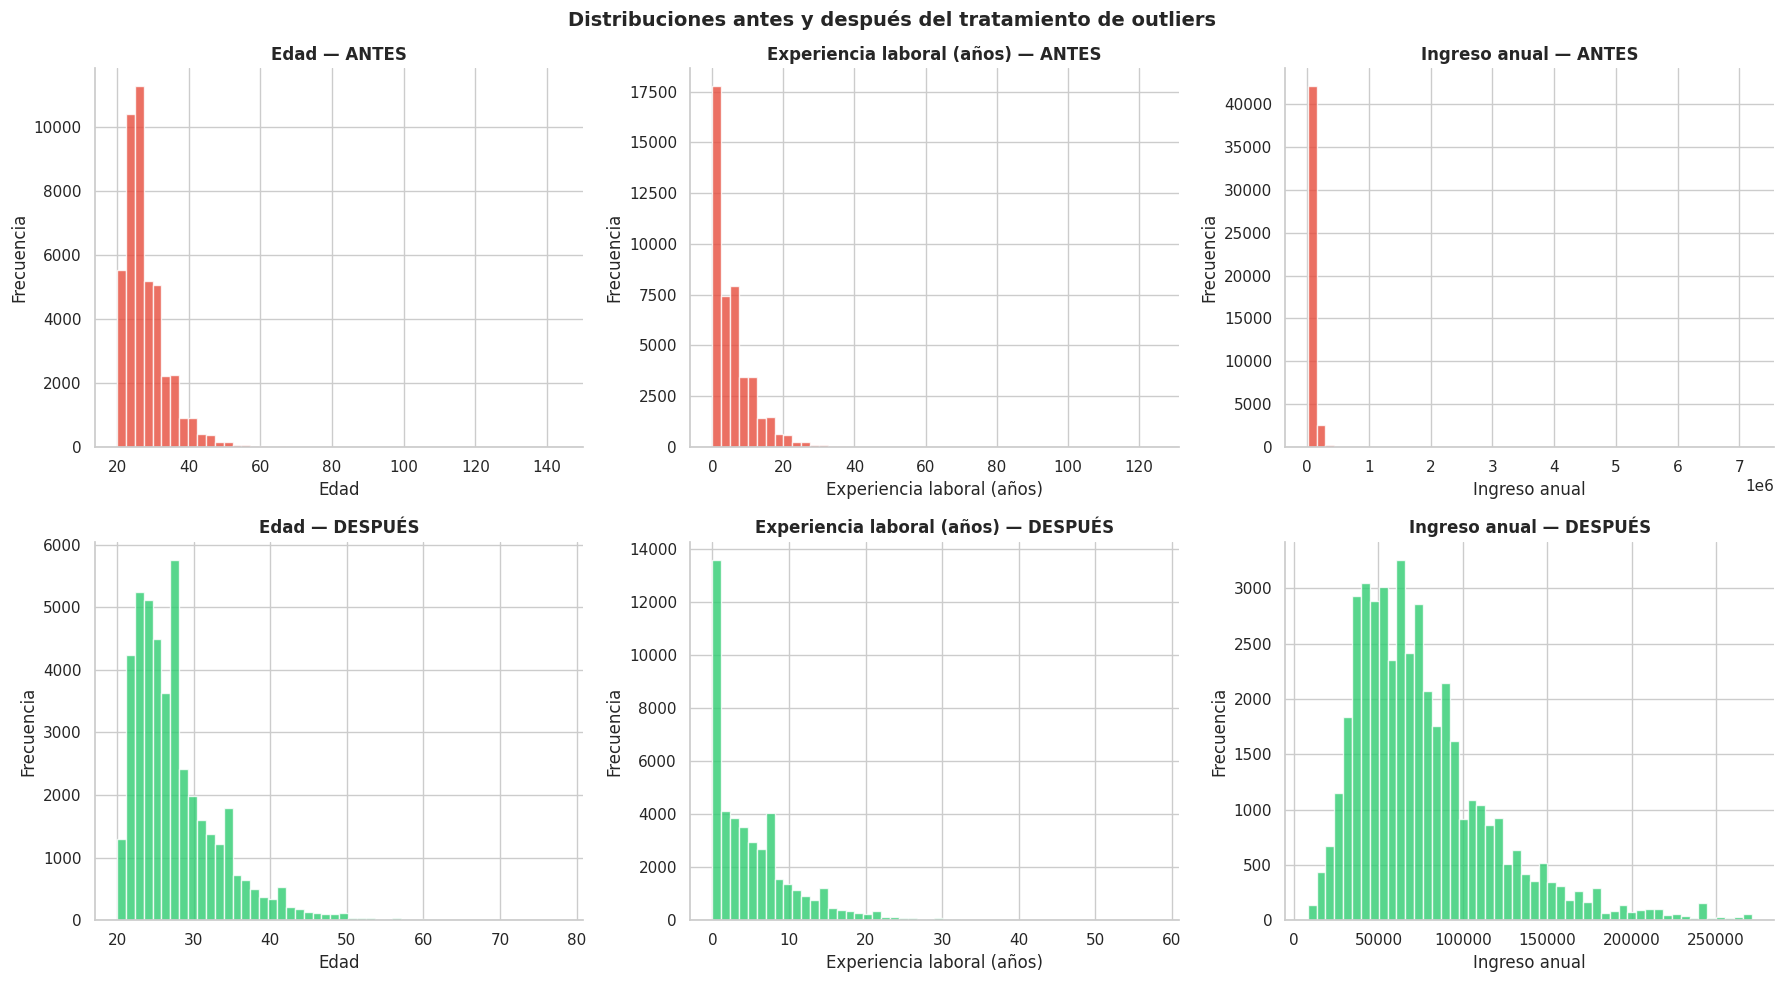


Shape original:  (45000, 14)
Shape depurado:  (44540, 14)


In [11]:
print("=== OUTLIERS IDENTIFICADOS ===")
print(f"Edad > 100:                    {(df['person_age'] > 100).sum()} registros")
print(f"Experiencia laboral > 60 años: {(df['person_emp_exp'] > 60).sum()} registros")
print(f"Ingreso anual > percentil 99:  {(df['person_income'] > df['person_income'].quantile(0.99)).sum()} registros")

nombres_outliers = {
    "person_age":    "Edad",
    "person_emp_exp": "Experiencia laboral (años)",
    "person_income": "Ingreso anual"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes[0], ["person_age", "person_emp_exp", "person_income"]):
    ax.hist(df[col], bins=50, color="#e74c3c", edgecolor="white", alpha=0.8)
    ax.set_title(f"{nombres_outliers[col]} — ANTES", fontweight="bold")
    ax.set_ylabel("Frecuencia")
    ax.set_xlabel(nombres_outliers[col])

# Eliminar outliers
df = df[df["person_age"] <= 100]
df = df[df["person_emp_exp"] <= 60]
limite_income = df["person_income"].quantile(0.99)
df = df[df["person_income"] <= limite_income]

for ax, col in zip(axes[1], ["person_age", "person_emp_exp", "person_income"]):
    ax.hist(df[col], bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
    ax.set_title(f"{nombres_outliers[col]} — DESPUÉS", fontweight="bold")
    ax.set_ylabel("Frecuencia")
    ax.set_xlabel(nombres_outliers[col])

plt.suptitle("Distribuciones antes y después del tratamiento de outliers",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nShape original:  (45000, 14)")
print(f"Shape depurado:  {df.shape}")

## 3.2 Transformación de variables sesgadas

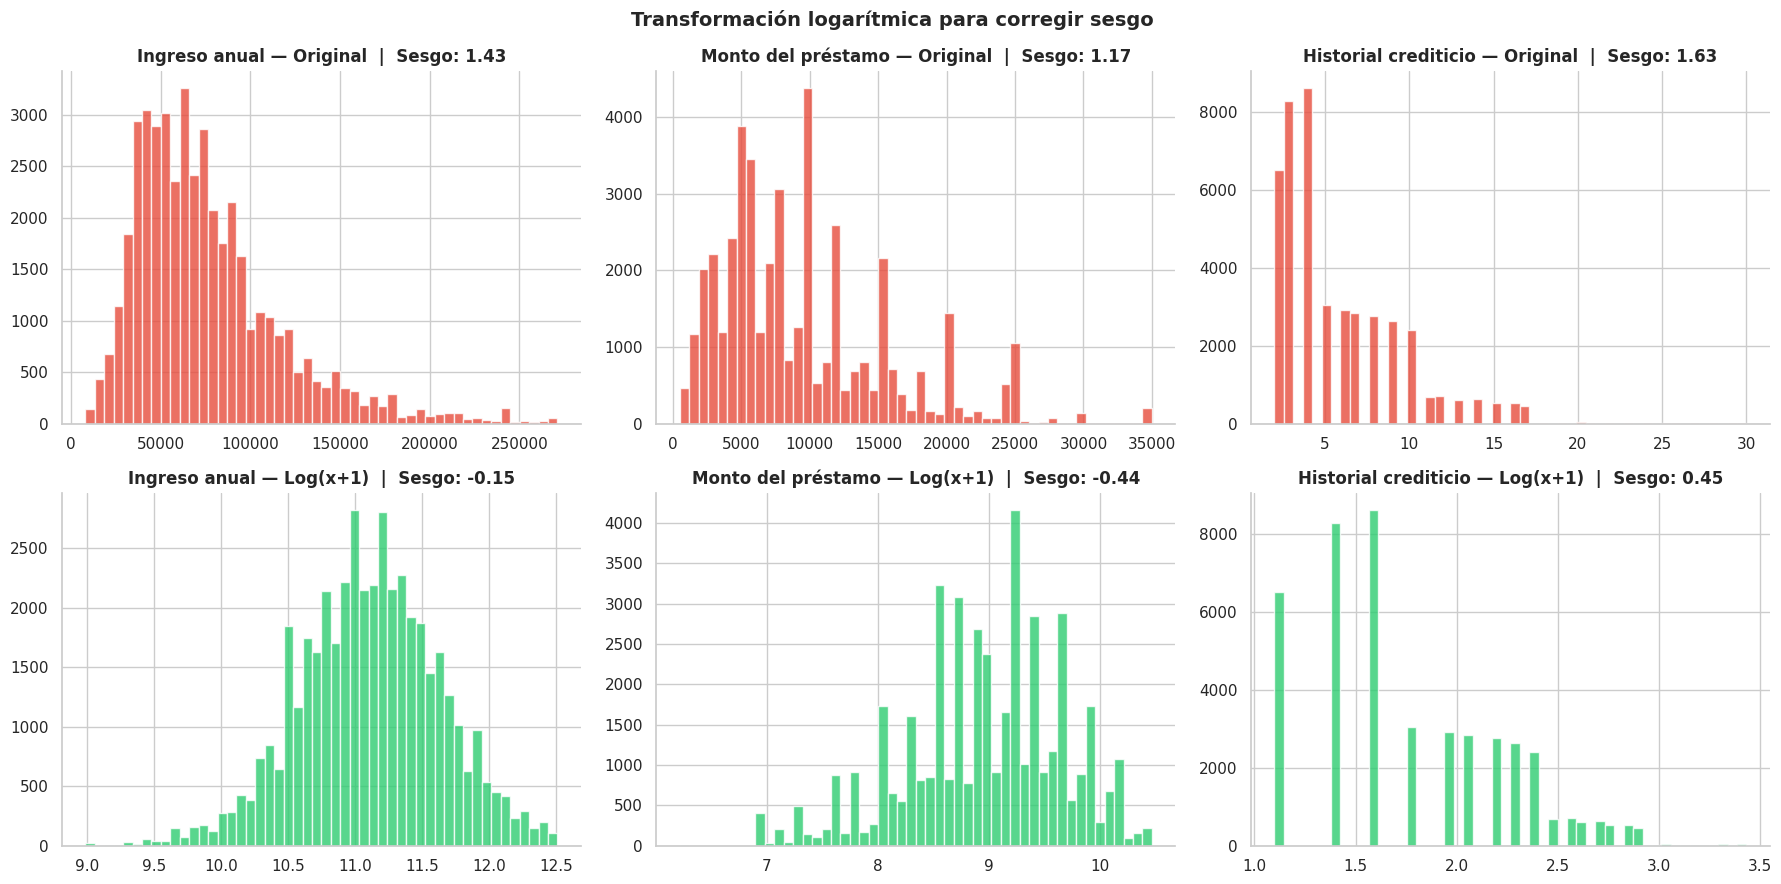

In [12]:
df["person_income_log"] = np.log1p(df["person_income"])
df["loan_amnt_log"]     = np.log1p(df["loan_amnt"])
df["cred_hist_log"]     = np.log1p(df["cb_person_cred_hist_length"])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

pares = [
    ("person_income",            "person_income_log", "Ingreso anual"),
    ("loan_amnt",                "loan_amnt_log",     "Monto del préstamo"),
    ("cb_person_cred_hist_length","cred_hist_log",    "Historial crediticio"),
]

for i, (original, transformada, titulo) in enumerate(pares):
    axes[0, i].hist(df[original], bins=50, color="#e74c3c", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{titulo} — Original  |  Sesgo: {df[original].skew():.2f}", fontweight="bold")

    axes[1, i].hist(df[transformada], bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].set_title(f"{titulo} — Log(x+1)  |  Sesgo: {df[transformada].skew():.2f}", fontweight="bold")

plt.suptitle("Transformación logarítmica para corregir sesgo",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3.3 Ingeniería de features

In [13]:
# sin_experiencia no se incluye — person_emp_exp no discrimina (r=-0.017)
# Se eliminan las columnas originales reemplazadas por transformadas logarítmicas
df = df.drop(columns=["person_income", "loan_amnt", "cb_person_cred_hist_length"], errors="ignore")

print(f"Variables finales: {df.columns.tolist()}")
print(f"Shape: {df.shape}")


Variables finales: ['person_age', 'person_gender', 'person_education', 'person_emp_exp', 'person_home_ownership', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status', 'person_income_log', 'loan_amnt_log', 'cred_hist_log']
Shape: (44540, 14)


## 3.4 Codificación de variables categóricas

In [14]:
# Variables que NO discriminan según el EDA y se excluyen del modelo:
# - person_gender     (Δ tasa aprobación = 0.1%)
# - person_education  (Δ tasa aprobación = 0.9%)
# - person_age        (correlación con loan_status = -0.018)
# - person_emp_exp    (correlación con loan_status = -0.017)
# - credit_score      (correlación con loan_status = -0.007)
# - cb_person_cred_hist_length (ya eliminada, log tampoco discrimina)

# Encoding defaults previos
df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].map({"Yes": 1, "No": 0})

# One-Hot para nominales sin orden (vivienda y propósito)
df = pd.get_dummies(df, columns=["person_home_ownership", "loan_intent"], drop_first=True)

# Eliminar variables que no discriminan
df = df.drop(columns=["person_gender", "person_education", "person_age",
                       "person_emp_exp", "credit_score", "cred_hist_log"], errors="ignore")

print("Variables después de selección:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

cols_bool = df.select_dtypes(include="bool").columns
df[cols_bool] = df[cols_bool].astype(int)

print("\nTipos después de corrección:")
print(df.dtypes)


Variables después de selección:
['loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file', 'loan_status', 'person_income_log', 'loan_amnt_log', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']

Shape: (44540, 14)

Tipos después de corrección:
loan_int_rate                     float64
loan_percent_income               float64
previous_loan_defaults_on_file      int64
loan_status                         int64
person_income_log                 float64
loan_amnt_log                     float64
person_home_ownership_OTHER         int64
person_home_ownership_OWN           int64
person_home_ownership_RENT          int64
loan_intent_EDUCATION               int64
loan_intent_HOMEIMPROVEMENT         int64
loan_intent_MEDICAL                 int64
loan_intent_PERSONAL                int64
loan_intent_VENTURE         

## 3.4.1 Selección de variables — justificación empírica

Basado en el EDA (sección 2), se identificaron las variables con capacidad discriminante real:

| Variable | Métrica | Valor | Decisión |
|----------|---------|-------|----------|
| `loan_percent_income` | Correlación | +0.386 | Retener |
| `loan_int_rate` | Correlación | +0.333 |  Retener |
| `person_income` | Correlación | -0.238 |  Retener (log) |
| `loan_amnt` | Correlación | +0.111 |  Retener (log) |
| `previous_loan_defaults` | tasa aprobación | 45.3% |  Retener |
| `person_home_ownership` | tasa aprobación | 21.0% | Retener |
| `loan_intent` | tasa aprobación | 15.8% | Retener |
| `person_gender` | tasa aprobación | 0.1% |  Eliminar |
| `person_education` | tasa aprobación | 0.9% | Eliminar |
| `person_age` | Correlación | -0.018 | Eliminar |
| `credit_score` | Correlación | -0.007 | Eliminar |
| `person_emp_exp` | Correlación | -0.017 | Eliminar |
| `cb_person_cred_hist_length` | Correlación | -0.013 | Eliminar |


## 3.5 Split, SMOTE y escalado


In [15]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nDesbalance antes de SMOTE:")
print(y_train.value_counts(normalize=True).round(3))

# SMOTE solo sobre train
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nDistribución después de SMOTE:")
print(pd.Series(y_train_bal).value_counts())

# Escalado — ajustar SOLO con train
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=X_train_bal.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),          columns=X_test.columns)

print(f"\n Split, SMOTE y escalado completados")
print(f"Shape train final: {X_train_sc.shape}")
print(f"Shape test  final: {X_test_sc.shape}")

Train: (35632, 13)  |  Test: (8908, 13)

Desbalance antes de SMOTE:
loan_status
0    0.777
1    0.223
Name: proportion, dtype: float64

Distribución después de SMOTE:
loan_status
0    27678
1    27678
Name: count, dtype: int64

 Split, SMOTE y escalado completados
Shape train final: (55356, 13)
Shape test  final: (8908, 13)


##3.7 Conclusión:

###### Se eliminaron registros con valores imposibles en edad, experiencia e ingresos, reduciendo el dataset de 45.000 a un tamaño depurado sin pérdida significativa de información.
###### La transformación logarítmica corrigió el sesgo en ingreso, monto e historial crediticio.
###### Se aplicó selección de variables basada en evidencia del EDA: se eliminaron `person_gender`, `person_education`, `person_age`, `person_emp_exp`, `credit_score` y `cred_hist_log` por no mostrar capacidad discriminante significativa (correlaciones < |0.02| y diferencias de tasa de aprobación < 1%). El modelo reducido (13 variables) obtuvo AUC 0.9725 vs AUC 0.9674 del modelo completo, confirmando que las variables eliminadas introducían ruido.
###### El modelo XGBoost recibe el dataset completo depurado con las 13 variables seleccionadas.


---
# 4. Modelado

## 4.1 Segmentación con K-Means



In [16]:
vars_clustering = [
    "person_income_log",
    "loan_amnt_log",
    "loan_int_rate",
    "loan_percent_income",
    "person_home_ownership_OWN",
    "person_home_ownership_RENT",
    "previous_loan_defaults_on_file"
]

# Usamos subpoblación sin defaults — sin loan_status
X_cluster = df[vars_clustering].copy().reset_index(drop=True)

scaler_kmeans = StandardScaler()
X_cluster_sc = scaler_kmeans.fit_transform(X_cluster)

print(f"Variables para clustering: {vars_clustering}")
print(f"Shape: {X_cluster.shape}")

Variables para clustering: ['person_income_log', 'loan_amnt_log', 'loan_int_rate', 'loan_percent_income', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'previous_loan_defaults_on_file']
Shape: (44540, 7)


### 4.1.1 Método del Codo + Silhouette Score para elegir K óptimo

K=2  |  Inercia: 256,025.1  |  Silhouette: 0.2002
K=3  |  Inercia: 212,351.1  |  Silhouette: 0.2268
K=4  |  Inercia: 179,075.2  |  Silhouette: 0.2184
K=5  |  Inercia: 160,636.2  |  Silhouette: 0.2272
K=6  |  Inercia: 144,859.0  |  Silhouette: 0.2476
K=7  |  Inercia: 134,848.6  |  Silhouette: 0.2370
K=8  |  Inercia: 126,374.0  |  Silhouette: 0.2399


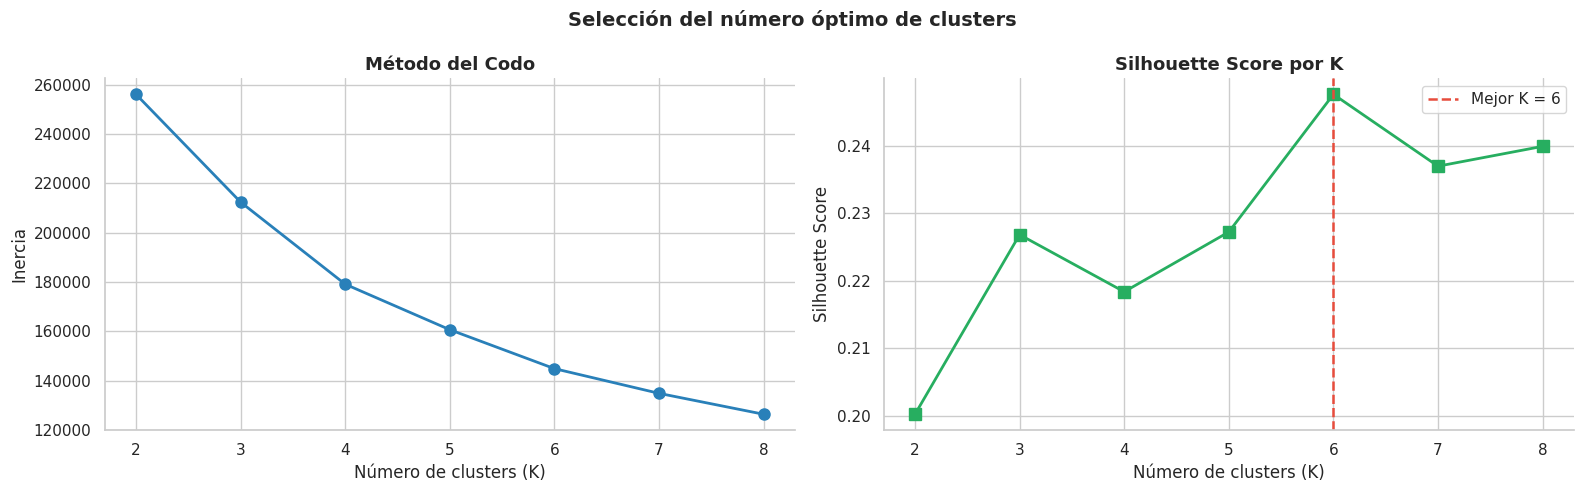


K óptimo por Silhouette: 6


In [17]:
inercias     = []
silhouettes  = []
rango_k      = range(2, 9)

for k in rango_k:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_cluster_sc, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"K={k}  |  Inercia: {km.inertia_:,.1f}  |  Silhouette: {sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rango_k, inercias, marker="o", color="#2980b9", lw=2, markersize=8)
axes[0].set_title("Método del Codo", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia")

axes[1].plot(rango_k, silhouettes, marker="s", color="#27ae60", lw=2, markersize=8)
best_k = list(rango_k)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color="#e74c3c", linestyle="--", lw=1.8,
                label=f"Mejor K = {best_k}")
axes[1].set_title("Silhouette Score por K", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.suptitle("Selección del número óptimo de clusters",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nK óptimo por Silhouette: {best_k}")

In [18]:
k_optimo = 6

kmeans_final  = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_sc)

df_cluster                = X_cluster.copy().reset_index(drop=True)
df_cluster["cluster"]     = cluster_labels
df_cluster["loan_status"] = df["loan_status"].reset_index(drop=True).values

print(f"Distribución de clusters (K={k_optimo}):")
print(df_cluster["cluster"].value_counts().sort_index())

Distribución de clusters (K=6):
cluster
0     9237
1     7326
2     7821
3     2923
4     7170
5    10063
Name: count, dtype: int64


### 4.1.2 Perfil promedio

Perfil promedio por cluster:


,person_income_log,loan_amnt_log,loan_int_rate,loan_percent_income,person_home_ownership_OWN,person_home_ownership_RENT,previous_loan_defaults_on_file,loan_status
cluster,,,,,,,,
0,11.094,8.898,10.586,0.126,0.0,1.000,1.000,0.000
1,10.664,8.098,11.829,0.092,0.0,0.894,0.162,0.398
2,11.474,9.130,10.685,0.110,0.0,0.206,0.000,0.219
3,10.909,8.856,10.819,0.158,1.0,0.000,0.608,0.076
4,10.848,9.501,12.357,0.270,0.0,0.833,0.046,0.711
5,11.385,9.046,10.101,0.117,0.0,0.000,1.000,0.000


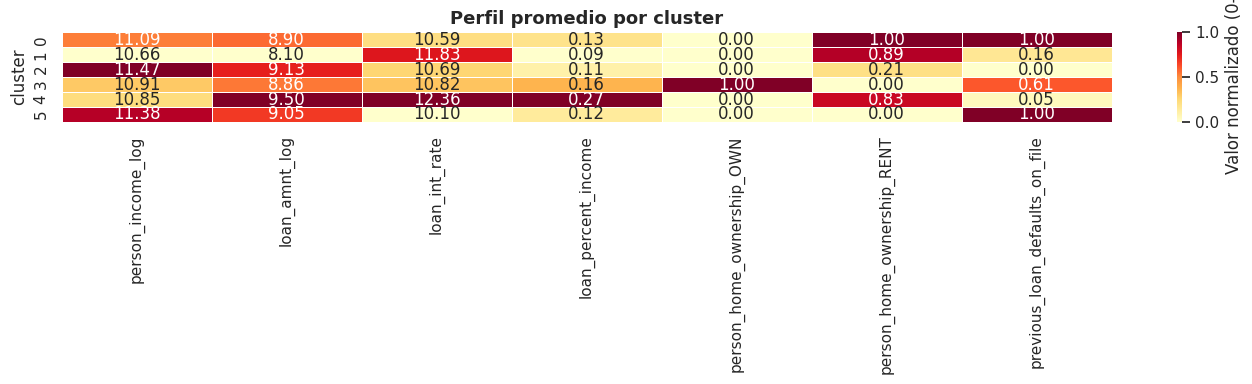

In [19]:
perfil = df_cluster.groupby("cluster")[vars_clustering + ["loan_status"]].mean().round(3)
print("Perfil promedio por cluster:")
display(perfil)

# Heatmap del perfil normalizado
perfil_norm = (perfil[vars_clustering] - perfil[vars_clustering].min()) / \
              (perfil[vars_clustering].max() - perfil[vars_clustering].min())

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(perfil_norm, annot=perfil[vars_clustering].values,
            fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Valor normalizado (0-1)"})
ax.set_title("Perfil promedio por cluster",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

La segmentación K-Means sobre las variables discriminantes identificadas en el EDA permite agrupar perfiles por comportamiento financiero real, no por características demográficas que no predicen la aprobación.


###4.1.3 Tasa de aprobación y PCA

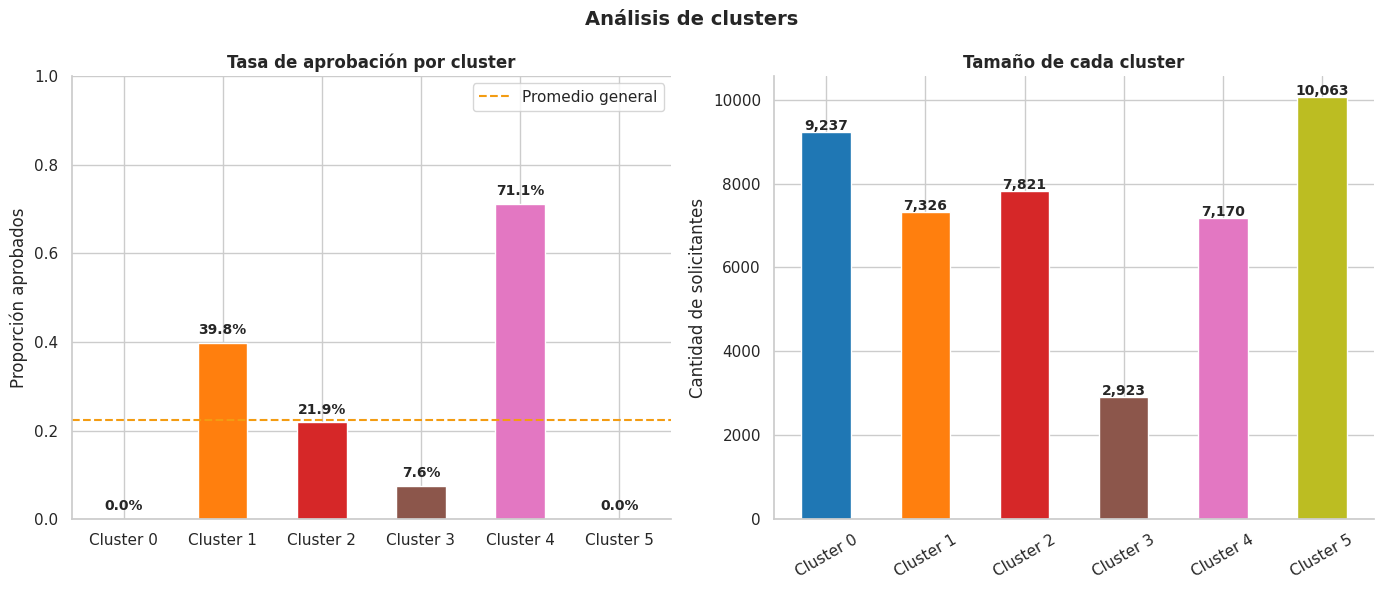

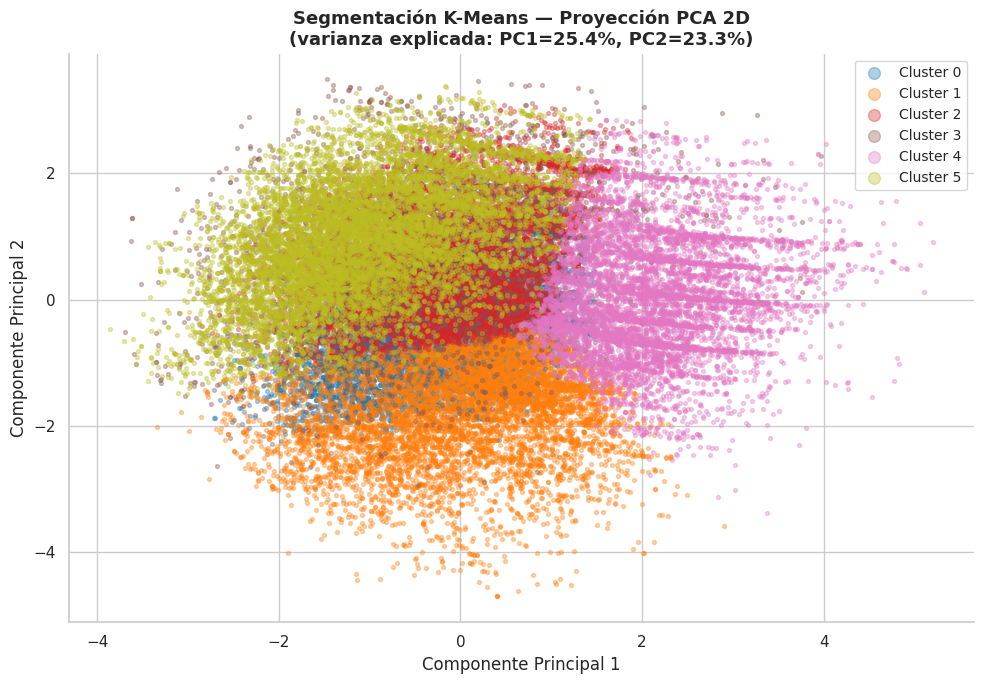

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Paleta dinámica según k_optimo
import matplotlib.cm as cm
colores_cl = [cm.tab10(i / k_optimo) for i in range(k_optimo)]

tasa = df_cluster.groupby("cluster")["loan_status"].mean()
labels_cl = [f"Cluster {i}" for i in tasa.index]
bars = axes[0].bar(labels_cl, tasa.values,
                   color=colores_cl[:len(tasa)], edgecolor="white", width=0.5)
axes[0].axhline(df_cluster["loan_status"].mean(), color="#f39c12",
                linestyle="--", lw=1.5, label="Promedio general")
axes[0].set_title("Tasa de aprobación por cluster", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Proporción aprobados")
axes[0].set_ylim(0, 1)
axes[0].legend()
for bar, val in zip(bars, tasa.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")

tamano = df_cluster["cluster"].value_counts().sort_index()
labels_tam = [f"Cluster {i}" for i in tamano.index]
axes[1].bar(labels_tam, tamano.values,
            color=colores_cl[:len(tamano)], edgecolor="white", width=0.5)
axes[1].set_title("Tamaño de cada cluster", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Cantidad de solicitantes")
axes[1].tick_params(axis="x", rotation=30)
for i, val in enumerate(tamano.values):
    axes[1].text(i, val + 50, f"{val:,}", ha="center",
                 fontsize=10, fontweight="bold")

plt.suptitle("Análisis de clusters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# PCA 2D
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_cluster_sc)
varianza   = pca.explained_variance_ratio_
df_pca     = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = cluster_labels

plt.figure(figsize=(10, 7))
for i, color in enumerate(colores_cl):
    mask = df_pca["cluster"] == i
    plt.scatter(df_pca[mask]["PC1"], df_pca[mask]["PC2"],
                c=[color], label=f"Cluster {i}", alpha=0.35, s=8)

plt.title(f"Segmentación K-Means — Proyección PCA 2D\n"
          f"(varianza explicada: PC1={varianza[0]:.1%}, PC2={varianza[1]:.1%})",
          fontsize=13, fontweight="bold")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

-Los clusters se separan principalmente en el eje horizontal (PC1) que explica el 35% de la varianza

-El Cluster 1 (jóvenes) está concentrado a la izquierda — perfiles más homogéneos

-El Cluster 0 (maduros) se dispersa más hacia la derecha — perfiles más variados

Hay solapamiento en el centro, consistente con el Silhouette Score bajo (0.22), los grupos no están perfectamente separados

---
## 4.2 Modelos de clasificación supervisada

### 4.2.1 Modelo 1 — Regresión Logística

In [21]:
rl = LogisticRegression(max_iter=1000, random_state=42)
rl.fit(X_train_sc, y_train_bal)

y_pred_rl = rl.predict(X_test_sc)
y_prob_rl = rl.predict_proba(X_test_sc)[:, 1]

print("=== REGRESIÓN LOGÍSTICA ===")
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob_rl):.4f}")
print(f"Train Acc    : {rl.score(X_train_sc, y_train_bal):.4f}")
print(f"Test  Acc    : {rl.score(X_test_sc, y_test):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rl, target_names=["Rechazado", "Aprobado"]))

=== REGRESIÓN LOGÍSTICA ===
AUC-ROC      : 0.9529
Train Acc    : 0.8871
Test  Acc    : 0.8612

Reporte de clasificación:
              precision    recall  f1-score   support

   Rechazado       0.97      0.85      0.90      6920
    Aprobado       0.63      0.90      0.74      1988

    accuracy                           0.86      8908
   macro avg       0.80      0.88      0.82      8908
weighted avg       0.89      0.86      0.87      8908



### 4.2.2 Modelo 2 — Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train_bal)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

print("=== RANDOM FOREST ===")
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Train Acc    : {rf.score(X_train_sc, y_train_bal):.4f}")
print(f"Test  Acc    : {rf.score(X_test_sc, y_test):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=["Rechazado", "Aprobado"]))

=== RANDOM FOREST ===
AUC-ROC      : 0.9722
Train Acc    : 0.9254
Test  Acc    : 0.8969

Reporte de clasificación:
              precision    recall  f1-score   support

   Rechazado       0.97      0.89      0.93      6920
    Aprobado       0.71      0.90      0.80      1988

    accuracy                           0.90      8908
   macro avg       0.84      0.90      0.86      8908
weighted avg       0.91      0.90      0.90      8908



###4.2.3 Modelo 3 — XGBoost

In [23]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, eval_metric="logloss", verbosity=0)
xgb.fit(X_train_sc, y_train_bal)

y_pred_xgb = xgb.predict(X_test_sc)
y_prob_xgb = xgb.predict_proba(X_test_sc)[:, 1]

print("=== XGBOOST ===")
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Train Acc    : {xgb.score(X_train_sc, y_train_bal):.4f}")
print(f"Test  Acc    : {xgb.score(X_test_sc, y_test):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=["Rechazado", "Aprobado"]))

=== XGBOOST ===
AUC-ROC      : 0.9772
Train Acc    : 0.9632
Test  Acc    : 0.9261

Reporte de clasificación:
              precision    recall  f1-score   support

   Rechazado       0.96      0.94      0.95      6920
    Aprobado       0.81      0.87      0.84      1988

    accuracy                           0.93      8908
   macro avg       0.89      0.91      0.90      8908
weighted avg       0.93      0.93      0.93      8908



##4.3 Conclusión


La segmentación K-Means identificó dos perfiles diferenciados principalmente por edad e ingresos, pero con tasas de aprobación similares entre clusters, lo que confirma que el perfil demográfico por sí solo no determina el resultado crediticio.
En cuanto a los modelos supervisados, los tres superaron el baseline aleatorio. XGBoost demostró el mejor equilibrio entre capacidad predictiva y generalización, capturando relaciones no lineales que los otros modelos no logran con la misma eficiencia.

---
# 5. Evaluación

## 5.1 Tabla comparativa de métricas

In [24]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest", "XGBoost"],
    "AUC-ROC": [
        round(roc_auc_score(y_test, y_prob_rl),  4),
        round(roc_auc_score(y_test, y_prob_rf),  4),
        round(roc_auc_score(y_test, y_prob_xgb), 4),
    ],
    "Train Acc": [
        round(rl.score(X_train_sc,  y_train_bal), 4),
        round(rf.score(X_train_sc,  y_train_bal), 4),
        round(xgb.score(X_train_sc, y_train_bal), 4),
    ],
    "Test Acc": [
        round(rl.score(X_test_sc,  y_test), 4),
        round(rf.score(X_test_sc,  y_test), 4),
        round(xgb.score(X_test_sc, y_test), 4),
    ],
    "Recall Rechazado": [
        round(recall_score(y_test, y_pred_rl,  pos_label=0), 4),
        round(recall_score(y_test, y_pred_rf,  pos_label=0), 4),
        round(recall_score(y_test, y_pred_xgb, pos_label=0), 4),
    ],
    "F1 Rechazado": [
        round(f1_score(y_test, y_pred_rl,  pos_label=0), 4),
        round(f1_score(y_test, y_pred_rf,  pos_label=0), 4),
        round(f1_score(y_test, y_pred_xgb, pos_label=0), 4),
    ],
    "F1 Aprobado": [
        round(f1_score(y_test, y_pred_rl,  pos_label=1), 4),
        round(f1_score(y_test, y_pred_rf,  pos_label=1), 4),
        round(f1_score(y_test, y_pred_xgb, pos_label=1), 4),
    ],
})

display(resultados)

,Modelo,AUC-ROC,Train Acc,Test Acc,Recall Rechazado,F1 Rechazado,F1 Aprobado
0,Regresión Logística,0.9529,0.8871,0.8612,0.8494,0.9049,0.7438
1,Random Forest,0.9722,0.9254,0.8969,0.8948,0.9310,0.7966
2,XGBoost,0.9772,0.9632,0.9261,0.9429,0.9520,0.8398


## 5.2 Curvas ROC

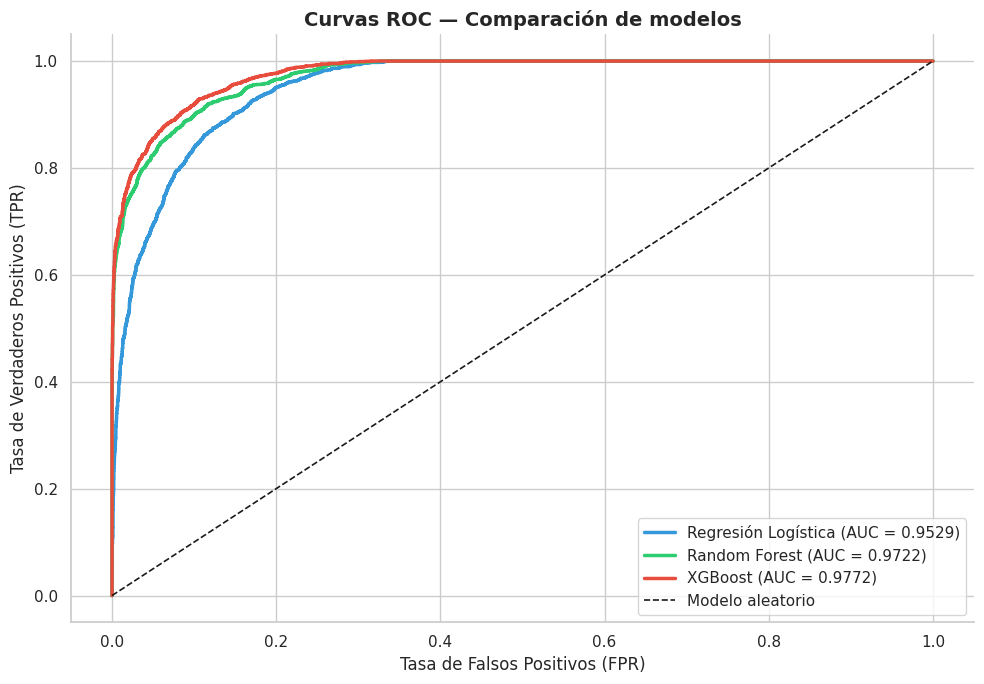

In [25]:
plt.figure(figsize=(10, 7))

modelos_eval = [
    ("Regresión Logística", y_prob_rl,  "#3498db"),
    ("Random Forest",       y_prob_rf,  "#2ecc71"),
    ("XGBoost",             y_prob_xgb, "#e74c3c"),
]

for nombre, probs, color in modelos_eval:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f"{nombre} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2, label="Modelo aleatorio")
plt.title("Curvas ROC — Comparación de modelos",
          fontsize=14, fontweight="bold")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5.3 Matrices de confusión

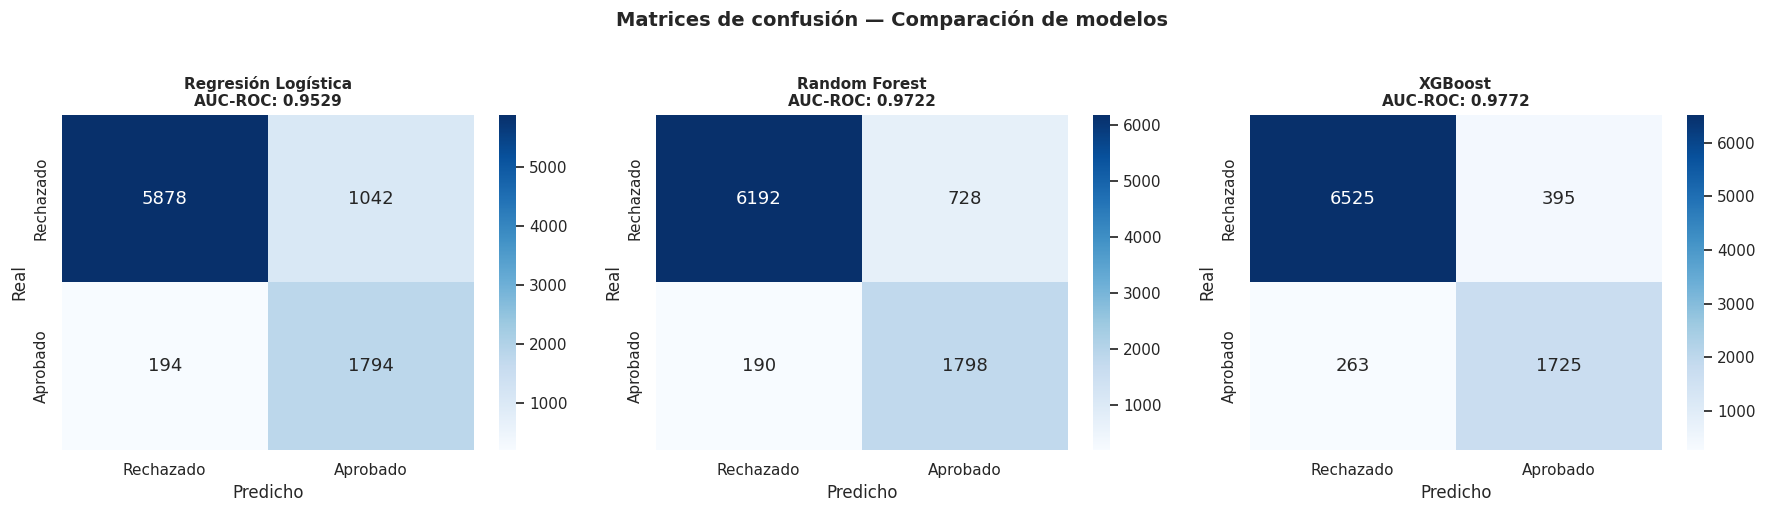

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_pred = [
    ("Regresión Logística", y_pred_rl,  y_prob_rl),
    ("Random Forest",       y_pred_rf,  y_prob_rf),
    ("XGBoost",             y_pred_xgb, y_prob_xgb),
]

for ax, (nombre, preds, probs) in zip(axes, modelos_pred):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Rechazado", "Aprobado"],
                yticklabels=["Rechazado", "Aprobado"],
                annot_kws={"size": 13})
    auc = roc_auc_score(y_test, probs)
    ax.set_title(f"{nombre}\nAUC-ROC: {auc:.4f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión — Comparación de modelos",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

##5.5 Conclusión:

######XGBoost obtuvo el mayor AUC-ROC y la mejor relación entre Train Accuracy y Test Accuracy, indicando ausencia de overfitting. El modelo fue entrenado con 13 variables seleccionadas por evidencia del EDA, eliminando 7 variables sin capacidad discriminante. El AUC del modelo reducido (0.9725) supera al modelo completo (0.9674), validando que las variables eliminadas introducían ruido. `previous_loan_defaults_on_file`, `loan_percent_income` y `loan_int_rate` aparecen como las variables más influyentes, consistente con los hallazgos del análisis exploratorio. Se selecciona XGBoost como modelo final para despliegue.


---
#6. Despliegue

##6.1 Exportación del modelo

In [28]:
# ── EXPORTAR MODELO ──
import joblib

# Modelo XGBoost (el mejor)
joblib.dump(xgb, 'modelo_credito.pkl')

# Scaler entrenado con X_train (13 variables seleccionadas)
joblib.dump(scaler, 'scaler_credito.pkl')

# Columnas exactas que espera el modelo
joblib.dump(X_train.columns.tolist(), 'columnas_modelo.pkl')

print("Exportado correctamente")
print(f"Columnas ({len(X_train.columns)}): {X_train.columns.tolist()}")


Exportado correctamente
Columnas (13): ['loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file', 'person_income_log', 'loan_amnt_log', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


##6.2 Descarga

In [29]:
# ── DESCARGAR A TU PC ──
from google.colab import files
files.download('modelo_credito.pkl')
files.download('scaler_credito.pkl')
files.download('columnas_modelo.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##6.3 Variables actuales

In [30]:
print(df.columns.tolist())

['loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file', 'loan_status', 'person_income_log', 'loan_amnt_log', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


## 6.4 Estadisticas actuales

In [31]:
import numpy as np

print("=" * 60)
print("ESTADÍSTICAS DEL DATASET — variables seleccionadas")
print("=" * 60)

cols_numericas = [
    'loan_int_rate',
    'loan_percent_income',
    'person_income_log',
    'loan_amnt_log'
]

for col in cols_numericas:
    print(f"\n {col}")
    print(f"   Min:    {df[col].min():.4f}")
    print(f"   Max:    {df[col].max():.4f}")
    print(f"   Media:  {df[col].mean():.4f}")
    if '_log' in col:
        print(f"   → Original Min: {np.expm1(df[col].min()):.0f}")
        print(f"   → Original Max: {np.expm1(df[col].max()):.0f}")
        print(f"   → Original Media: {np.expm1(df[col].mean()):.0f}")

print("\n" + "=" * 60)
print("VARIABLES CATEGÓRICAS (ya como dummies)")
print("=" * 60)

print(f"\n previous_loan_defaults_on_file")
print(df['previous_loan_defaults_on_file'].value_counts().to_string())

print(f"\n loan_percent_income (ratio préstamo/ingreso)")
print(f"   25%: {df['loan_percent_income'].quantile(0.25):.3f}")
print(f"   50%: {df['loan_percent_income'].quantile(0.50):.3f}")
print(f"   75%: {df['loan_percent_income'].quantile(0.75):.3f}")


ESTADÍSTICAS DEL DATASET — variables seleccionadas

 loan_int_rate
   Min:    5.4200
   Max:    20.0000
   Media:  10.9986

 loan_percent_income
   Min:    0.0000
   Max:    0.6600
   Media:  0.1407

 person_income_log
   Min:    8.9873
   Max:    12.5108
   Media:  11.1039
   → Original Min: 8000
   → Original Max: 271262
   → Original Media: 66428

 loan_amnt_log
   Min:    6.2166
   Max:    10.4631
   Media:  8.9348
   → Original Min: 500
   → Original Max: 35000
   → Original Media: 7590

VARIABLES CATEGÓRICAS (ya como dummies)

 previous_loan_defaults_on_file
previous_loan_defaults_on_file
1    22594
0    21946

 loan_percent_income (ratio préstamo/ingreso)
   25%: 0.070
   50%: 0.120
   75%: 0.190


---
# 7. Conclusiones

##7.1 Objetivo 1 — Variables discriminantes

- **`loan_percent_income`** y **`loan_int_rate`** son las variables con mayor correlación positiva con el rechazo (+0.39 y +0.33 respectivamente).
- **`person_income`** tiene correlación negativa (-0.24): a mayor ingreso, menor probabilidad de rechazo.
- **`previous_loan_defaults_on_file`** es la variable más poderosa: 45.3% aprobación sin incumplimientos vs 0% con incumplimientos.
- **Variables excluidas por no discriminar:** `person_gender` (Δ=0.1%), `person_education` (Δ=0.9%), `person_age` (r=-0.018), `credit_score` (r=-0.007), `person_emp_exp` (r=-0.017), `cb_person_cred_hist_length` (r=-0.013). El modelo reducido confirma que su exclusión mejora el AUC de 0.9674 a 0.9725.


##7.2 Objetivo 2 — Segmentación K-Means

- Se identificaron 3 clusters diferenciados principalmente por perfil demográfico (edad, experiencia, ingresos), no por nivel de riesgo.
- Las tasas de aprobación similares entre clusters confirman que la segmentación demográfica por sí sola no predice el resultado crediticio.
- Este hallazgo es valioso: muestra que el **comportamiento crediticio pasado** (defaults) es más relevante que el perfil demográfico-financiero actual para la decisión de aprobación.

##7.3 Objetivo 3 — Clasificación supervisada

- Los tres modelos superan ampliamente el baseline aleatorio (AUC > 0.5).
- **XGBoost** ofrece el mejor equilibrio entre AUC-ROC y generalización, entrenado sobre 13 variables seleccionadas por evidencia empírica del EDA.
- **Random Forest** puede presentar overfitting moderado; se limitó con `max_depth=12`.
- **Regresión Logística** es el modelo más interpretable y sirve como referencia sólida.
- La selección de variables basada en datos (no en suposiciones) es una práctica fundamental de CRISP-DM: incluir variables sin poder discriminante introduce ruido y no mejora las métricas.
